In [20]:
import yfinance
import pandas as pd
import ta
import matplotlib.pyplot as plt
import optuna
from numpy import tri

In [21]:
data = yfinance.download("AAPL", start="2020-01-01",end = "2025-01-01")
data = data.reset_index("Date")

C:\Users\samue\AppData\Local\Temp\ipykernel_24200\1757415865.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yfinance.download("AAPL", start="2020-01-01",end = "2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [22]:
data_2 = pd.DataFrame()
data_2["Close"] = data.Close
data_2["High"] = data.High
data_2["Low"] = data.Low
data_2["Open"] = data.Open
data_2['Date'] = data.Date

In [23]:
# constants
com = 0.125/100
# variables
cash=1_000_000
active_long_positions = []
active_short_positions = []
portfolio_value = [cash]
positions_counts=0

#hiperparametros
rsi_lower = 30
rsi_upper = 70
rsi_window = 11
n_shares=100
sl=0.05
tp=0.05

rsi_ind = ta.momentum.RSIIndicator(data_2.Close, window = rsi_window)
data_2['rsi'] = rsi_ind.rsi()

data_2 = data_2.dropna()

for i, row in data_2.iterrows():
  # Risk management
  # close long position
  for pos in active_long_positions.copy():
      value = row.Close * n_shares
      # closing SL
      if value <= pos["sl"]:
        print("Closing position SL limit reached")
        cash += row.Close * n_shares * (1-com)
        active_long_positions.remove(pos)

      # closing tp
      if value >= pos["tp"]:
        print("Closing position TP limit reached")
        cash += row.Close * n_shares * (1-com)
        active_long_positions.remove(pos)

  # close short position

  # Trading signals
  buy_signal = row.rsi < rsi_lower
  sell_signal = row.rsi > rsi_upper

  if buy_signal:
    total_cost = row.Close * n_shares * (1+com)
    # check if we have enough cash..
    if cash > total_cost:
      cash -= total_cost
      active_long_positions.append({
          "type":"long",
          "n_shares":n_shares,
          "bought_at":row.Close,
          "sl":row.Close*n_shares*(1-sl),
          "tp":row.Close*n_shares*(1+tp)
      })
      positions_counts += 1

  #Portfolio value
  long_vals = len(active_long_positions) * n_shares * row.Close
  #short_vals = ...

  portfolio_value.append((cash + long_vals)) # add short value here short_vals

Closing position SL limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position SL limit reached
Closing position SL limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position SL limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing position SL limit reached
Closing position TP limit reached
Closing position TP limit reached
Closing positi

Text(0.5, 1.0, 'positions:37- ret:22133.34107017517')

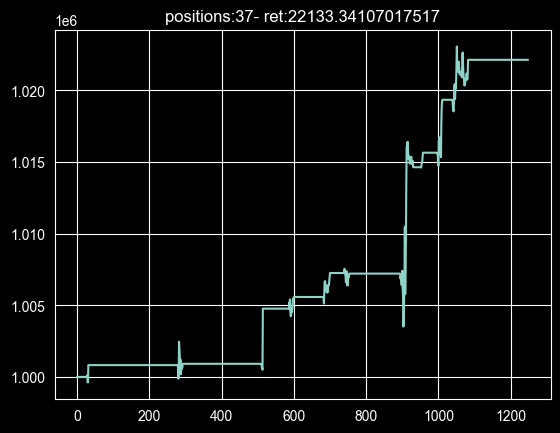

In [25]:
start_ = 1_000_000
end_ = portfolio_value[-1]
plt.plot(portfolio_value)
plt.title(f"positions:{positions_counts} - ret:{end_-start_}")

### **Modelo TPE**

In [ ]:
from numpy import tri
def objective():
  # constants
  com = 0.125/100
  # variables
  cash=1_000_000
  active_long_positions = []
  active_short_positions = []
  portfolio_value = [cash]
  positions_counts=0

  #hiperparametros
  rsi_lower = trial.suggest_int("rsi_lower", 10, 40)
  rsi_upper = 70
  rsi_window = trial.suggest_int("rsi_window", 5, 80)
  n_shares= trial.suggest_categorical("n_shares", [100,150,200,250,1000])
  sl=trial.suggest_float("sl", 0.01, 0.12)
  tp=trial.suggest_float("tp", 0.01, 0.12)

  rsi_ind = ta.momentum.RSIIndicator(data_2.Close, window = rsi_window)
  data_2['rsi'] = rsi_ind.rsi()

  data_2 = data_2.dropna()

  for i, row in data_2.iterrows():
    # Risk management
    # close long position
    for pos in active_long_positions.copy():
        value = row.Close * n_shares
        # closing SL
        if value <= pos["sl"]:
          print("Closing position SL limit reached")
          cash += row.Close * n_shares * (1-com)
          active_long_positions.remove(pos)

        # closing tp
        if value >= pos["tp"]:
          print("Closing position TP limit reached")
          cash += row.Close * n_shares * (1-com)
          active_long_positions.remove(pos)



    # close short position

    # Trading signals
    buy_signal = row.rsi < rsi_lower
    sell_signal = row.rsi > rsi_upper

    if buy_signal:
      total_cost = row.Close * n_shares * (1+com)
      # check if we have enough cash..
      if cash > total_cost:
        cash -= total_cost
        active_long_positions.append({
            "type":"long",
            "n_shares":n_shares,
            "bought_at":row.Close,
            "sl":row.Close*n_shares*(1-sl),
            "tp":row.Close*n_shares*(1+tp)
        })
        positions_counts += 1

    #Portfolio value
    long_vals = len(active_long_positions) * n_shares * row.Close
    #short_vals = ...

    portfolio_value.append((cash + long_vals)) # add short value here short_vals


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(lambda x: objective, n_trials=100)  # no esta completa

In [ ]:
study.best_params